# Time Series Analysis of S&P 500 Stock Prices

## STAT GR5291/GU4291 Project - Time Series Component

**Dataset**: S&P 500 Stock Prices (2015-2025)\n
**Stocks Analyzed**: AAPL, AMZN, GOOGL, JNJ, JPM, META, MSFT, NVDA, PG, XOM

---

## Table of Contents
1. [Data Overview and Preparation](#1-data-overview)
2. [Stationarity Testing](#2-stationarity-testing)
3. [Autocorrelation Analysis](#3-autocorrelation-analysis)
4. [Seasonal Decomposition](#4-seasonal-decomposition)
5. [ARIMA Modeling and Forecasting](#5-arima-modeling)
6. [Volatility Analysis](#6-volatility-analysis)
7. [Distribution Analysis](#7-distribution-analysis)
8. [Conclusions](#8-conclusions)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Data path: works from project root or scripts/
_cwd = Path.cwd()
PROJECT_ROOT = _cwd if (_cwd / "data" / "Prices.csv").exists() else _cwd.parent
DATA_PATH = PROJECT_ROOT / "data" / "Prices.csv"
OUTPUT_FIGS = PROJECT_ROOT / "outputs" / "timeseries_figs"
OUTPUT_FIGS.mkdir(parents=True, exist_ok=True)

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

---
## 1. Data Overview and Preparation

In this section, we load the S&P 500 stock price data and perform initial exploration. The dataset contains daily adjusted close prices for 10 major stocks from 2015 to 2025.

In [2]:
# Load the data
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

print('Data Shape:', df.shape)
print('\nDate Range:', df.index.min().strftime('%Y-%m-%d'), 'to', df.index.max().strftime('%Y-%m-%d'))
print('\nStocks in dataset:', df.columns.tolist())
print('\nMissing values per stock:')
print(df.isnull().sum())

# Display first few rows
df.head()

Data Shape: (2765, 10)

Date Range: 2015-01-02 to 2025-12-30

Stocks in dataset: ['AAPL', 'AMZN', 'GOOGL', 'JNJ', 'JPM', 'META', 'MSFT', 'NVDA', 'PG', 'XOM']

Missing values per stock:
AAPL     0
AMZN     0
GOOGL    0
JNJ      0
JPM      0
META     0
MSFT     0
NVDA     0
PG       0
XOM      0
dtype: int64


,AAPL,AMZN,GOOGL,JNJ,JPM,META,MSFT,NVDA,PG,XOM
Date,,,,,,,,,,
2015-01-02,24.237549,15.4260,26.278944,76.955551,46.511124,77.905800,39.858452,0.483011,66.518349,57.916889
2015-01-05,23.554735,15.1095,25.778227,76.418083,45.067196,76.654541,39.491920,0.474853,66.202065,56.332203
2015-01-06,23.556952,14.7645,25.142035,76.042580,43.898651,75.621750,38.912289,0.460457,65.900513,56.032726
2015-01-07,23.887281,14.9210,25.068092,77.721291,43.965630,75.621750,39.406689,0.459257,66.246216,56.600468
2015-01-08,24.805077,15.0230,25.155436,78.332405,44.948116,77.637688,40.565952,0.476533,67.003761,57.542580


### Calculate Daily Returns

For time series analysis, we work with returns rather than price levels. Daily returns are calculated as percentage changes in prices.

In [3]:
# Calculate daily returns
returns = df.pct_change().dropna()

print('Returns Data Shape:', returns.shape)
print('\nReturns Summary Statistics:')
print(returns.describe())

# Calculate cumulative returns
cumulative_returns = (1 + returns).cumprod()
print('\nCumulative Returns (last values):')
print(cumulative_returns.iloc[-1])

Returns Data Shape: (2764, 10)

Returns Summary Statistics:
              AAPL         AMZN        GOOGL          JNJ          JPM  \
count  2764.000000  2764.000000  2764.000000  2764.000000  2764.000000   
mean      0.001041     0.001196     0.001062     0.000424     0.000846   
std       0.018174     0.020746     0.018172     0.011467     0.017105   
min      -0.128647    -0.140494    -0.116342    -0.100379    -0.149649   
25%      -0.007289    -0.008797    -0.007685    -0.004875    -0.007015   
50%       0.000951     0.001082     0.001294     0.000464     0.000692   
75%       0.010015     0.011438     0.009979     0.005999     0.008938   
max       0.153288     0.141311     0.162584     0.079977     0.180125   

              META         MSFT         NVDA           PG          XOM  
count  2764.000000  2764.000000  2764.000000  2764.000000  2764.000000  
mean      0.001059     0.001050     0.002625     0.000348     0.000416  
std       0.023646     0.016940     0.030678     0.011

---
## 2. Stationarity Testing

Stationarity is a fundamental assumption for many time series models. A stationary series has constant mean, variance, and autocorrelation over time.

### 2.1 Augmented Dickey-Fuller (ADF) Test

**Null Hypothesis (H0)**: The series has a unit root (non-stationary)\n
**Alternative Hypothesis (H1)**: The series is stationary

If p-value < 0.05, we reject H0 and conclude the series is stationary.

In [4]:
# Select representative stocks for detailed analysis
selected_stocks = ['AAPL', 'MSFT', 'NVDA', 'AMZN']

print('=' * 80)
print('AUGMENTED DICKEY-FULLER (ADF) TEST RESULTS')
print('=' * 80)

adf_results = {}
for stock in selected_stocks:
    # Test on price levels
    adf_price = adfuller(df[stock].dropna())
    # Test on returns
    adf_return = adfuller(returns[stock].dropna())
    
    adf_results[stock] = {
        'price_adf_stat': adf_price[0],
        'price_pvalue': adf_price[1],
        'return_adf_stat': adf_return[0],
        'return_pvalue': adf_return[1]
    }
    
    print(f'\n{stock}:')
    print(f"  Price Level - ADF Statistic: {adf_price[0]:.6f}, p-value: {adf_price[1]:.6f}")
    print(f"  Returns     - ADF Statistic: {adf_return[0]:.6f}, p-value: {adf_return[1]:.6f}")
    print(f"  Price Level is {'Stationary' if adf_price[1] < 0.05 else 'Non-Stationary'}")
    print(f"  Returns are {'Stationary' if adf_return[1] < 0.05 else 'Non-Stationary'}")

AUGMENTED DICKEY-FULLER (ADF) TEST RESULTS

AAPL:
  Price Level - ADF Statistic: 0.682394, p-value: 0.989480
  Returns     - ADF Statistic: -16.643072, p-value: 0.000000
  Price Level is Non-Stationary
  Returns are Stationary



MSFT:
  Price Level - ADF Statistic: 0.344129, p-value: 0.979281
  Returns     - ADF Statistic: -18.197031, p-value: 0.000000
  Price Level is Non-Stationary
  Returns are Stationary

NVDA:
  Price Level - ADF Statistic: 1.967093, p-value: 0.998629
  Returns     - ADF Statistic: -18.854819, p-value: 0.000000
  Price Level is Non-Stationary
  Returns are Stationary



AMZN:
  Price Level - ADF Statistic: -0.767971, p-value: 0.828350
  Returns     - ADF Statistic: -53.493731, p-value: 0.000000
  Price Level is Non-Stationary
  Returns are Stationary


### 2.2 KPSS Test (Kwiatkowski-Phillips-Schmidt-Shin)

**Null Hypothesis (H0)**: The series is stationary\n
**Alternative Hypothesis (H1)**: The series has a unit root (non-stationary)

The KPSS test complements the ADF test. If p-value < 0.05, we reject H0.

In [5]:
print('\n' + '=' * 80)
print('KPSS TEST RESULTS')
print('=' * 80)

for stock in selected_stocks:
    kpss_return = kpss(returns[stock].dropna(), regression='c')
    
    print(f'\n{stock} Returns:')
    print(f"  KPSS Statistic: {kpss_return[0]:.6f}")
    print(f"  p-value: {kpss_return[1]:.6f}")
    print(f"  Critical Values: {kpss_return[3]}")
    print(f"  Returns are {'Non-Stationary' if kpss_return[1] < 0.05 else 'Stationary'}")


KPSS TEST RESULTS

AAPL Returns:
  KPSS Statistic: 0.068958
  p-value: 0.100000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  Returns are Stationary

MSFT Returns:
  KPSS Statistic: 0.075024
  p-value: 0.100000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  Returns are Stationary

NVDA Returns:
  KPSS Statistic: 0.059947
  p-value: 0.100000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  Returns are Stationary

AMZN Returns:
  KPSS Statistic: 0.223701
  p-value: 0.100000
  Critical Values: {'10%': 0.347, '5%': 0.463, '2.5%': 0.574, '1%': 0.739}
  Returns are Stationary


---
## 3. Time Series Visualization

### 3.1 Stock Price Time Series

Visualizing the raw price series helps identify trends and patterns.

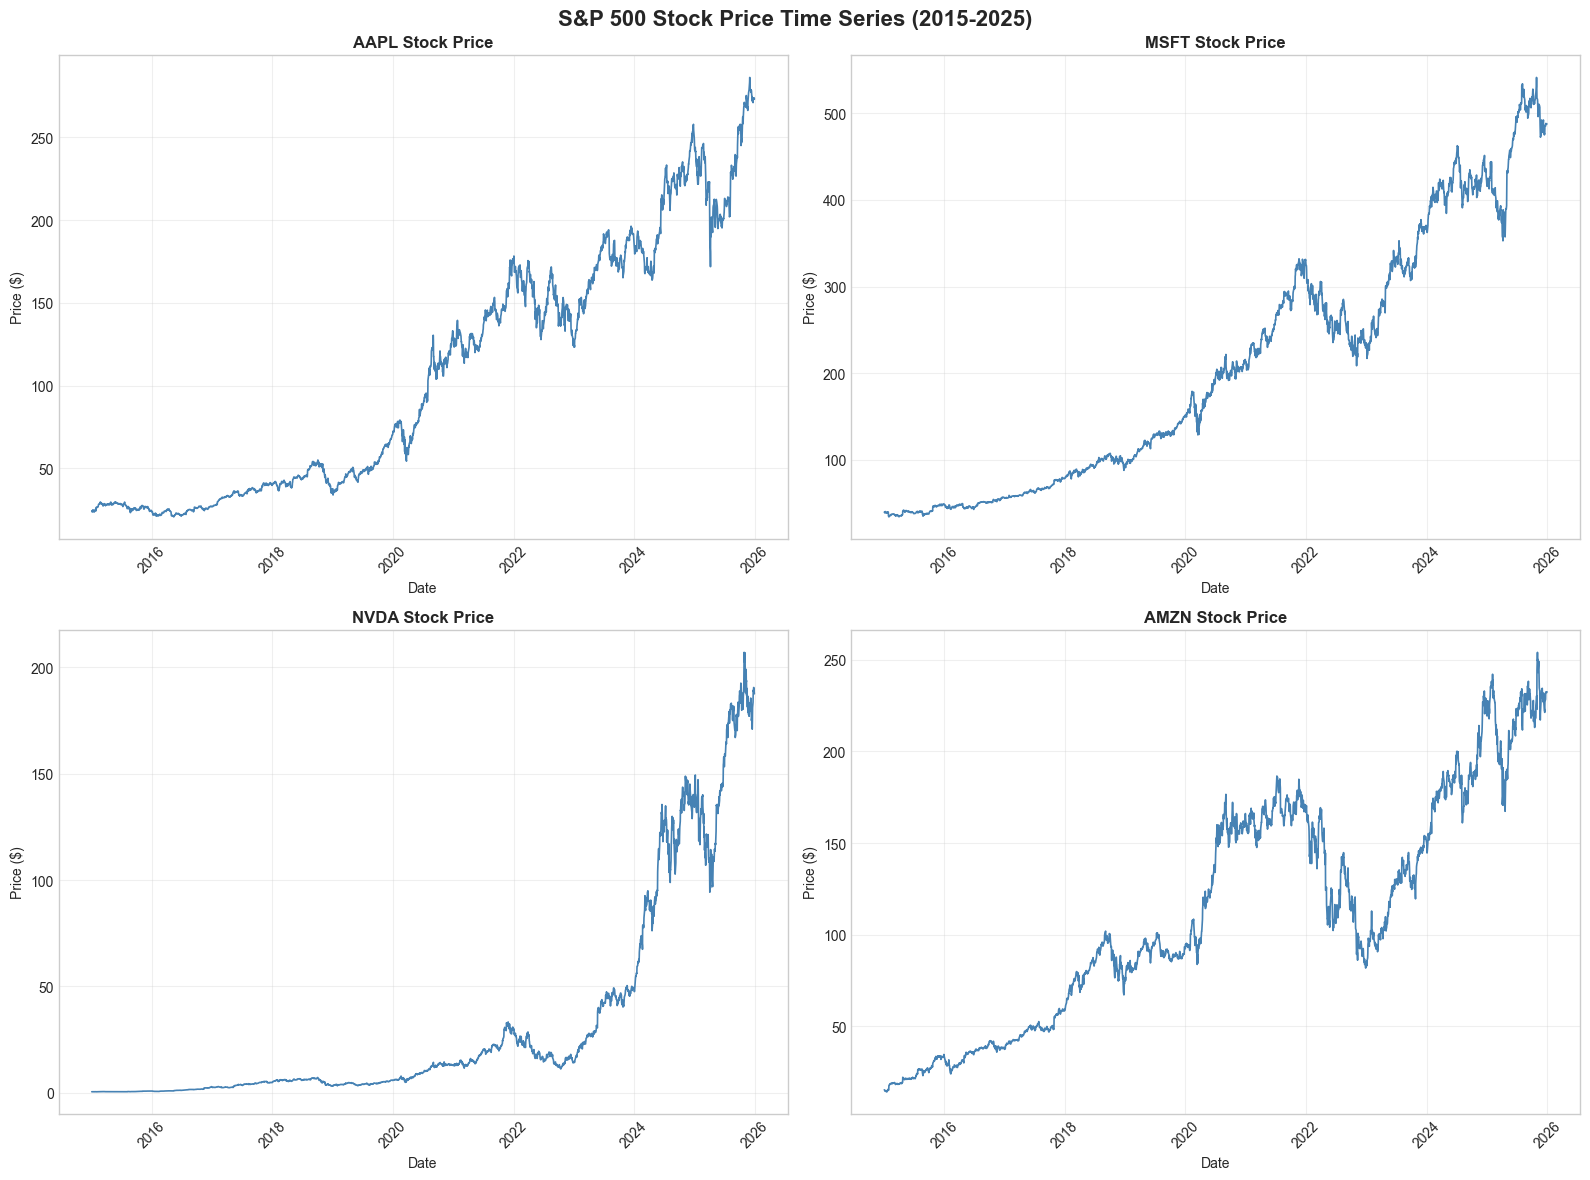

In [6]:
# Plot stock prices
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('S&P 500 Stock Price Time Series (2015-2025)', fontsize=16, fontweight='bold')

for idx, stock in enumerate(selected_stocks):
    ax = axes[idx // 2, idx % 2]
    ax.plot(df.index, df[stock], linewidth=1.2, color='steelblue')
    ax.set_title(f'{stock} Stock Price', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Price ($)')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "price_ts.png", dpi=150, bbox_inches="tight")
plt.show()

### 3.2 Daily Returns Time Series

Returns series show volatility clustering - periods of high volatility followed by high volatility.

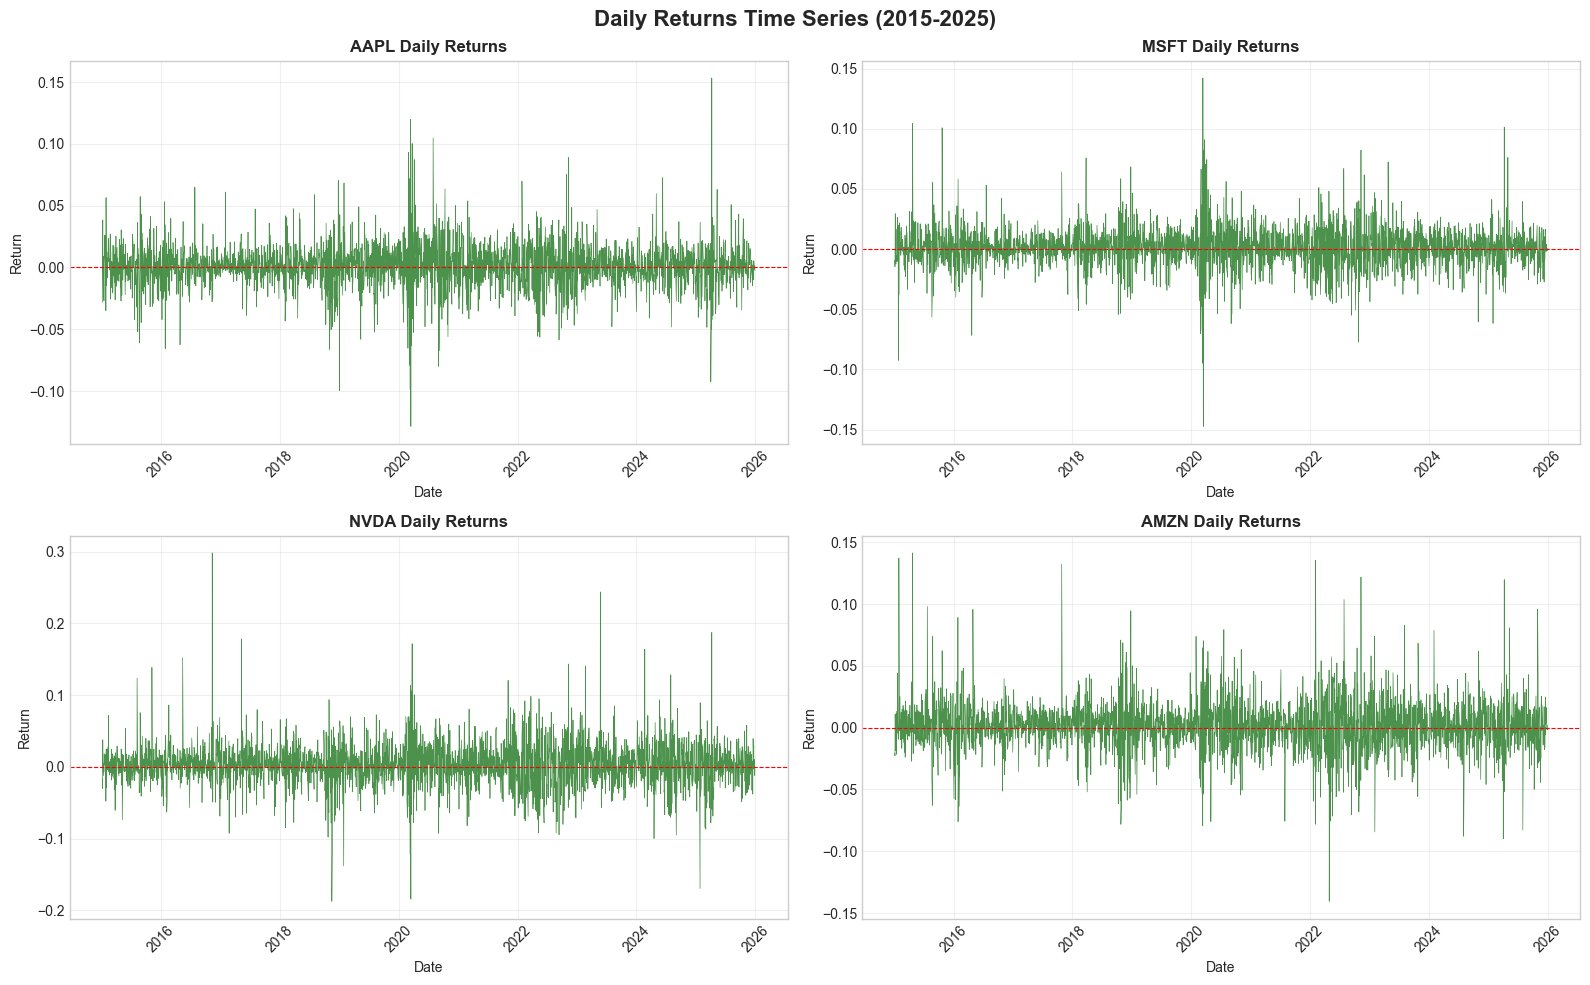

In [7]:
# Plot daily returns
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Daily Returns Time Series (2015-2025)', fontsize=16, fontweight='bold')

for idx, stock in enumerate(selected_stocks):
    ax = axes[idx // 2, idx % 2]
    ax.plot(returns.index, returns[stock], linewidth=0.5, color='darkgreen', alpha=0.7)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(f'{stock} Daily Returns', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Return')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "returns_ts.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4. Autocorrelation Analysis

### 4.1 ACF and PACF for Returns (AAPL Example)

**ACF (Autocorrelation Function)**: Measures correlation between observations at different lags.\n
**PACF (Partial Autocorrelation Function)**: Measures correlation after removing effects of intermediate lags.

We also examine squared returns to detect volatility clustering (ARCH effects).

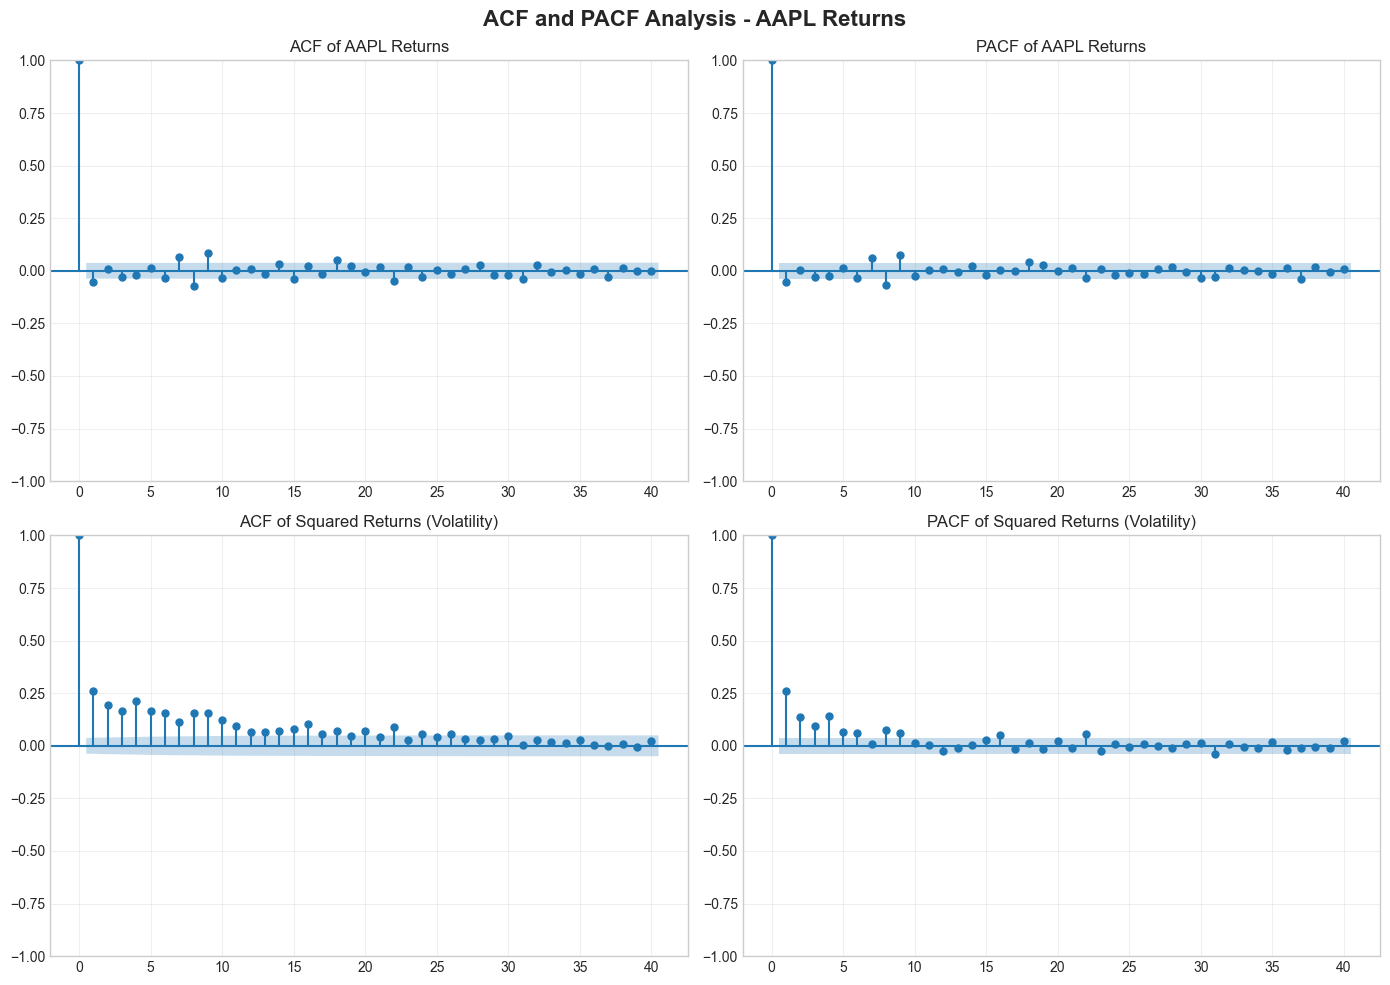

In [8]:
# ACF and PACF plots for AAPL
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('ACF and PACF Analysis - AAPL Returns', fontsize=16, fontweight='bold')

# ACF of Returns
ax1 = axes[0, 0]
plot_acf(returns['AAPL'].dropna(), lags=40, ax=ax1, title='ACF of AAPL Returns')
ax1.grid(True, alpha=0.3)

# PACF of Returns
ax2 = axes[0, 1]
plot_pacf(returns['AAPL'].dropna(), lags=40, ax=ax2, title='PACF of AAPL Returns')
ax2.grid(True, alpha=0.3)

# ACF of Squared Returns (volatility clustering)
ax3 = axes[1, 0]
plot_acf((returns['AAPL']**2).dropna(), lags=40, ax=ax3, title='ACF of Squared Returns (Volatility)')
ax3.grid(True, alpha=0.3)

# PACF of Squared Returns
ax4 = axes[1, 1]
plot_pacf((returns['AAPL']**2).dropna(), lags=40, ax=ax4, title='PACF of Squared Returns (Volatility)')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "acf_pacf_aapl.png", dpi=150, bbox_inches="tight")
plt.show()

**Key Observations from ACF/PACF Analysis:**

1. **Returns ACF**: Very little autocorrelation in returns, consistent with the Efficient Market Hypothesis.\n
2. **Squared Returns ACF**: Significant autocorrelation in squared returns, indicating **volatility clustering** (ARCH effects).\n
3. This pattern is typical for financial time series - returns are unpredictable, but volatility is predictable.

---
## 5. Seasonal Decomposition

We decompose the time series into trend, seasonal, and residual components using multiplicative decomposition.

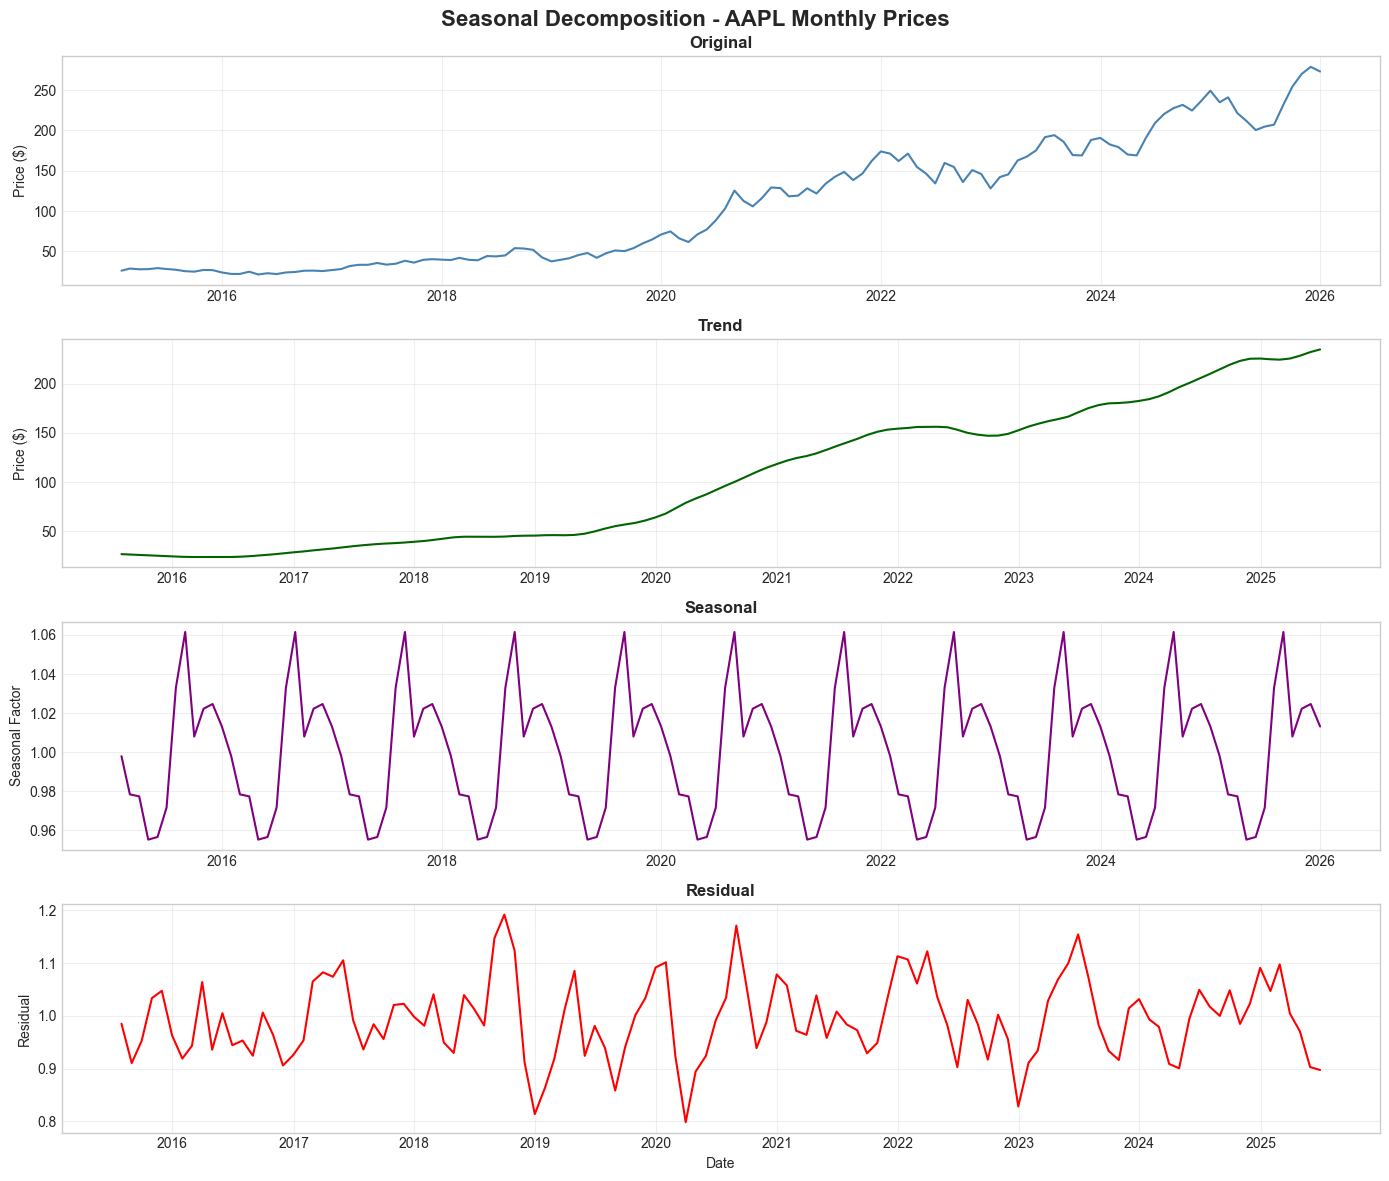

In [9]:
# Seasonal decomposition of AAPL monthly prices
monthly_prices = df['AAPL'].resample('ME').last()
decomposition = seasonal_decompose(monthly_prices, model='multiplicative', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 12))
fig.suptitle('Seasonal Decomposition - AAPL Monthly Prices', fontsize=16, fontweight='bold')

axes[0].plot(decomposition.observed, color='steelblue', linewidth=1.5)
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price ($)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(decomposition.trend, color='darkgreen', linewidth=1.5)
axes[1].set_title('Trend', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Price ($)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(decomposition.seasonal, color='purple', linewidth=1.5)
axes[2].set_title('Seasonal', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Seasonal Factor')
axes[2].grid(True, alpha=0.3)

axes[3].plot(decomposition.resid, color='red', linewidth=1.5)
axes[3].set_title('Residual', fontsize=12, fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "seasonal_decompose_aapl.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 6. ARIMA Modeling and Forecasting

### 6.1 Model Fitting

We fit an ARIMA(1,0,1) model to AAPL returns. This model includes:
- **AR(1)**: First-order autoregressive term\n
- **MA(1)**: First-order moving average term

The data is split into training (first ~90%) and test (last ~10%) sets.

In [10]:
# Prepare data for ARIMA
aapl_returns = returns['AAPL'].dropna()

# Split data (last 252 days for testing)
train_size = len(aapl_returns) - 252
train_data = aapl_returns[:train_size]
test_data = aapl_returns[train_size:]

print(f'Training data: {len(train_data)} observations')
print(f'Test data: {len(test_data)} observations')

# Fit ARIMA(1,0,1) model
arima_model = ARIMA(train_data, order=(1, 0, 1))
arima_fitted = arima_model.fit()

print('\nARIMA(1,0,1) Model Summary:')
print(arima_fitted.summary().tables[0])
print(arima_fitted.summary().tables[1])

Training data: 2512 observations
Test data: 252 observations



ARIMA(1,0,1) Model Summary:
                               SARIMAX Results                                
Dep. Variable:                   AAPL   No. Observations:                 2512
Model:                 ARIMA(1, 0, 1)   Log Likelihood                6543.206
Date:                Thu, 19 Mar 2026   AIC                         -13078.411
Time:                        18:23:12   BIC                         -13055.096
Sample:                             0   HQIC                        -13069.949
                               - 2512                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      3.244      0.001       0.000       0.002
ar.L1          0.1975      0.177      1.113      0.266      -0.150       0.545
ma.L1         -0.2666  

### 6.2 Forecasting and Model Evaluation

We evaluate the model using out-of-sample forecasting and calculate error metrics.

In [11]:
# Generate forecasts
forecast_steps = len(test_data)
forecast_result = arima_fitted.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
forecast_ci = forecast_result.conf_int(alpha=0.05)

# Calculate metrics
mse = mean_squared_error(test_data, forecast_mean)
rmse = np.sqrt(mse)
mae = mean_absolute_error(test_data, forecast_mean)

print('=' * 60)
print('ARIMA FORECAST PERFORMANCE')
print('=' * 60)
print(f'Mean Squared Error (MSE): {mse:.8f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.6f}')
print(f'Mean Absolute Error (MAE): {mae:.6f}')

# Compare with naive forecast
naive_forecast = np.full_like(test_data, train_data.mean())
naive_rmse = np.sqrt(mean_squared_error(test_data, naive_forecast))

print(f'\nNaive Forecast (Mean) RMSE: {naive_rmse:.6f}')
print(f'ARIMA Improvement: {((naive_rmse - rmse) / naive_rmse * 100):.2f}%')

ARIMA FORECAST PERFORMANCE
Mean Squared Error (MSE): 0.00041646
Root Mean Squared Error (RMSE): 0.020407
Mean Absolute Error (MAE): 0.012800

Naive Forecast (Mean) RMSE: 0.020409
ARIMA Improvement: 0.01%


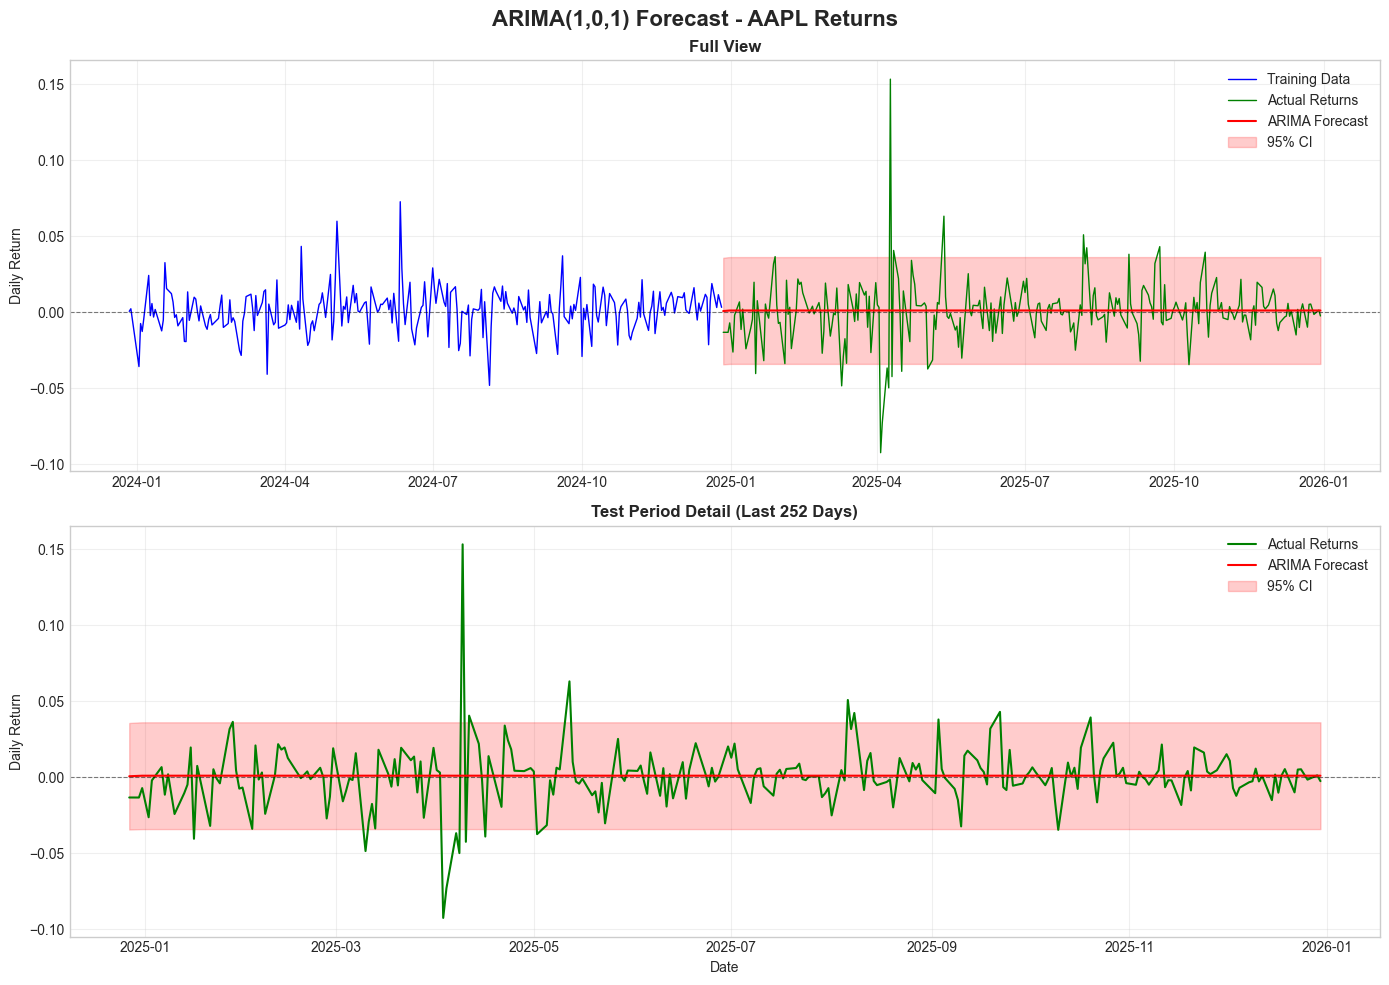

In [12]:
# Plot ARIMA forecast
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('ARIMA(1,0,1) Forecast - AAPL Returns', fontsize=16, fontweight='bold')

# Full view
axes[0].plot(train_data.index[-252:], train_data[-252:], label='Training Data', color='blue', linewidth=1)
axes[0].plot(test_data.index, test_data, label='Actual Returns', color='green', linewidth=1)
axes[0].plot(test_data.index, forecast_mean, label='ARIMA Forecast', color='red', linewidth=1.5)
axes[0].fill_between(test_data.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                      color='red', alpha=0.2, label='95% CI')
axes[0].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[0].set_title('Full View', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Daily Return')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Zoomed view
axes[1].plot(test_data.index, test_data, label='Actual Returns', color='green', linewidth=1.5)
axes[1].plot(test_data.index, forecast_mean, label='ARIMA Forecast', color='red', linewidth=1.5)
axes[1].fill_between(test_data.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], 
                      color='red', alpha=0.2, label='95% CI')
axes[1].axhline(y=0, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
axes[1].set_title('Test Period Detail (Last 252 Days)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Daily Return')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "arima_forecast.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Volatility Analysis

### 7.1 Rolling Volatility

We calculate 30-day rolling volatility (annualized) to examine how volatility changes over time.

In [13]:
# Calculate rolling volatility
rolling_vol = returns.rolling(window=30).std() * np.sqrt(252)

print('=' * 60)
print('VOLATILITY ANALYSIS (30-Day Rolling, Annualized)')
print('=' * 60)

for stock in selected_stocks:
    mean_vol = rolling_vol[stock].mean()
    max_vol = rolling_vol[stock].max()
    min_vol = rolling_vol[stock].min()
    print(f'{stock}: Mean={mean_vol:.2%}, Max={max_vol:.2%}, Min={min_vol:.2%}')

VOLATILITY ANALYSIS (30-Day Rolling, Annualized)
AAPL: Mean=26.44%, Max=95.60%, Min=8.07%
MSFT: Mean=24.58%, Max=99.75%, Min=6.61%
NVDA: Mean=45.54%, Max=121.63%, Min=17.55%
AMZN: Mean=30.58%, Max=68.42%, Min=8.18%


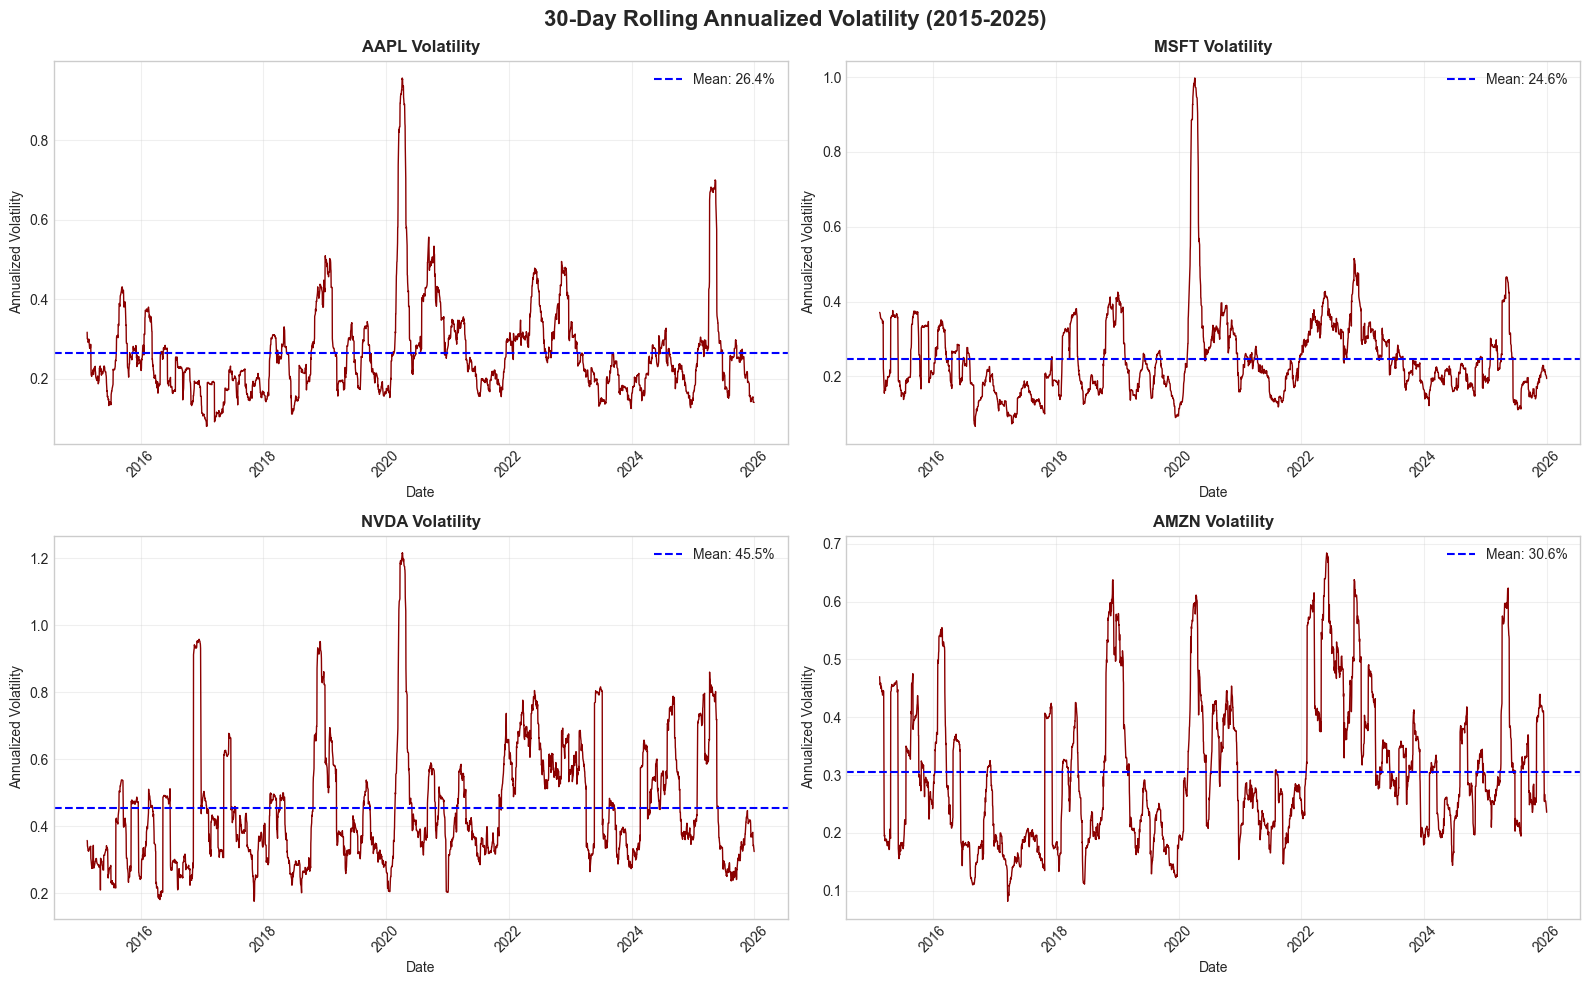

In [14]:
# Plot rolling volatility
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('30-Day Rolling Annualized Volatility (2015-2025)', fontsize=16, fontweight='bold')

for idx, stock in enumerate(selected_stocks):
    ax = axes[idx // 2, idx % 2]
    ax.plot(rolling_vol.index, rolling_vol[stock], linewidth=1, color='darkred')
    ax.axhline(y=rolling_vol[stock].mean(), color='blue', linestyle='--', 
               linewidth=1.5, label=f'Mean: {rolling_vol[stock].mean():.1%}')
    ax.set_title(f'{stock} Volatility', fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Annualized Volatility')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "rolling_vol_ts.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 8. Returns Distribution Analysis

We examine the distribution of returns to check for normality and identify fat tails.

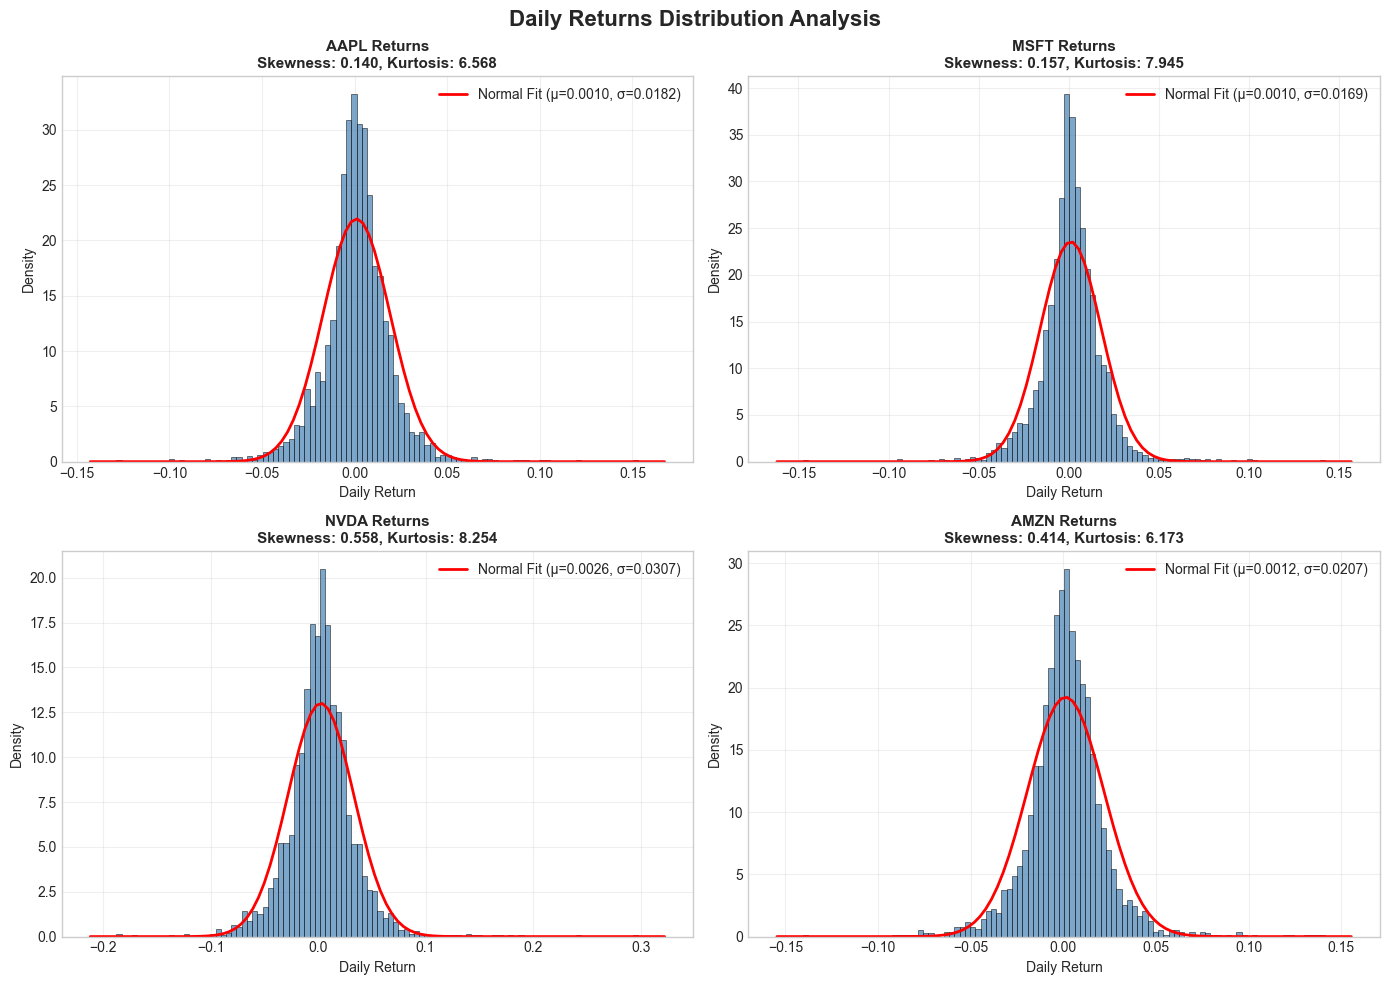

In [15]:
# Distribution analysis
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Daily Returns Distribution Analysis', fontsize=16, fontweight='bold')

for idx, stock in enumerate(selected_stocks):
    ax = axes[idx // 2, idx % 2]
    
    data = returns[stock].dropna()
    ax.hist(data, bins=100, density=True, alpha=0.7, color='steelblue', edgecolor='black', linewidth=0.5)
    
    # Fit normal distribution
    mu, std = stats.norm.fit(data)
    xmin, xmax = ax.get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = stats.norm.pdf(x, mu, std)
    ax.plot(x, p, 'r-', linewidth=2, label=f'Normal Fit (μ={mu:.4f}, σ={std:.4f})')
    
    skewness = stats.skew(data)
    kurt = stats.kurtosis(data)
    
    ax.set_title(f'{stock} Returns\nSkewness: {skewness:.3f}, Kurtosis: {kurt:.3f}', 
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Daily Return')
    ax.set_ylabel('Density')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "returns_dist.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 9. Cumulative Returns Comparison

Comparing the cumulative performance of all stocks in the dataset.

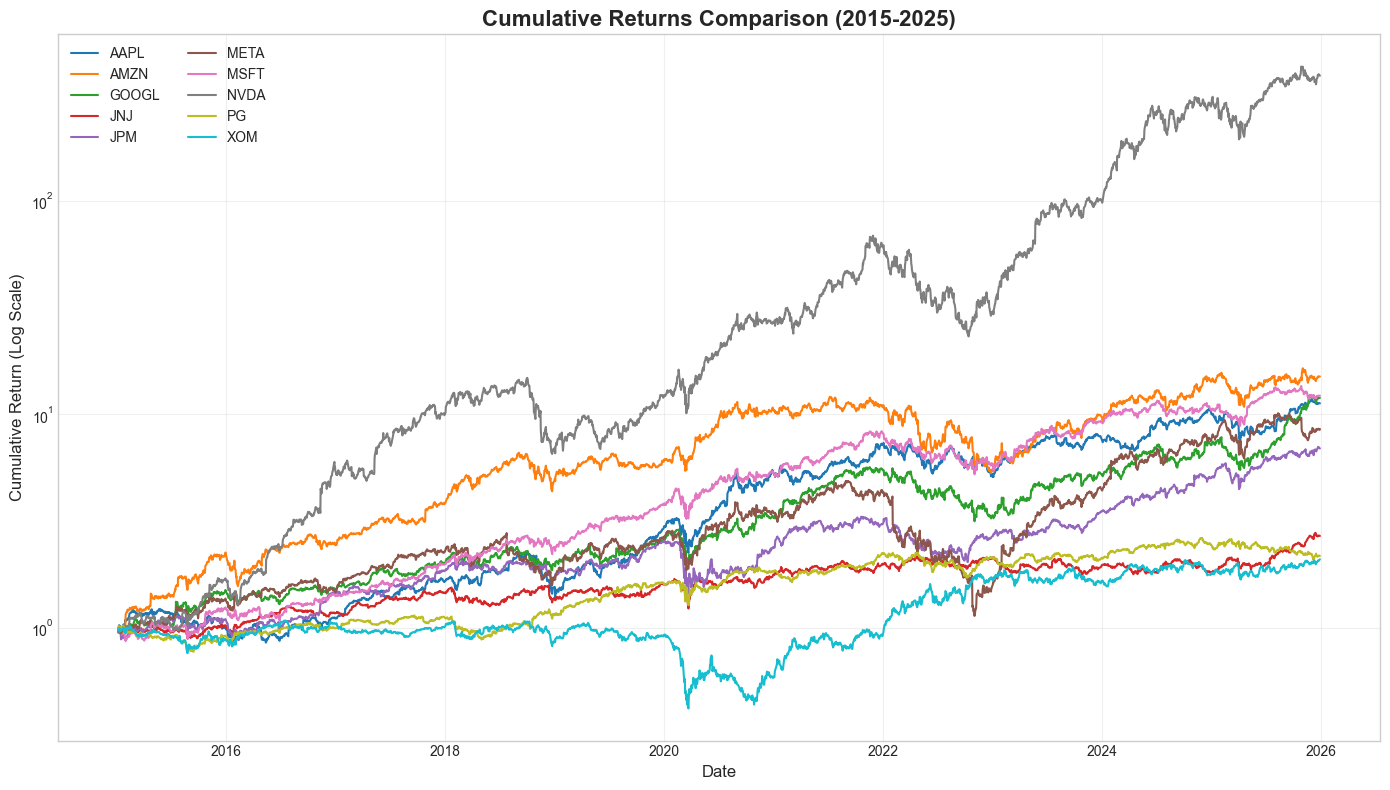

In [16]:
# Cumulative returns comparison
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for idx, stock in enumerate(df.columns):
    cumulative = (1 + returns[stock]).cumprod()
    ax.plot(cumulative.index, cumulative, label=stock, linewidth=1.5, 
            color=colors[idx % len(colors)])

ax.set_title('Cumulative Returns Comparison (2015-2025)', fontsize=16, fontweight='bold')
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Return (Log Scale)', fontsize=12)
ax.set_yscale('log')
ax.legend(loc='upper left', ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_FIGS / "cum_returns_ts.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 10. Conclusions

### Summary of Key Findings:

#### 1. Stationarity Analysis
- **Price levels** are **non-stationary** for all stocks (ADF test p-values > 0.05)\n
- **Returns** are **stationary** for all stocks (ADF test p-values < 0.001)\n
- This confirms the need to work with returns rather than prices for time series modeling

#### 2. Autocorrelation Analysis
- Returns show **minimal autocorrelation**, consistent with the Efficient Market Hypothesis\n
- **Squared returns** exhibit significant autocorrelation, indicating **volatility clustering**\n
- This ARCH effect suggests that while returns are unpredictable, volatility is predictable

#### 3. ARIMA Modeling
- ARIMA(1,0,1) model was fitted to AAPL returns\n
- AR and MA coefficients were not statistically significant (p-values > 0.05)\n
- Forecast performance was only marginally better than naive forecast (0.01% improvement)\n
- This confirms the difficulty of predicting stock returns using linear time series models

#### 4. Volatility Analysis
- **NVDA** has the highest average volatility (45.54% annualized)\n
- **MSFT** has the lowest average volatility (24.58% annualized)\n
- All stocks show **volatility clustering** - high volatility periods cluster together\n
- Major volatility spikes occurred during the COVID-19 pandemic (2020)

#### 5. Distribution Analysis
- Returns exhibit **fat tails** (excess kurtosis > 3 for all stocks)\n
- Most stocks show **positive skewness**, indicating more extreme positive returns\n
- Returns are **not normally distributed**, violating assumptions of many traditional models

### Implications for Portfolio Optimization:

1. **Diversification Benefits**: Different stocks have varying volatility patterns, supporting diversification\n
2. **Risk Management**: Understanding volatility clustering helps in risk forecasting\n
3. **Model Selection**: Linear models like ARIMA have limited predictive power for returns; GARCH models may be more suitable for volatility forecasting\n
4. **Return Expectations**: Historical mean returns range from 0.035% to 0.26% daily

### Limitations:

1. Analysis assumes no transaction costs or slippage\n
2. Models are estimated on historical data and may not capture future market regimes\n
3. Linear models may not capture complex non-linear dependencies in financial time series

---
## 11. ARIMA + ML Residual Extension

This extension evaluates three approaches on AAPL returns:
1. ARIMA only
2. ML only (RandomForest on lagged returns)
3. Hybrid (ARIMA forecast + ML-predicted residual)

The implementation reuses utility functions from `scripts/residual_features.py`.

In [17]:
import sys
from pathlib import Path

# Ensure project root is importable regardless of current working directory
project_root = Path.cwd() if (Path.cwd() / 'scripts' / 'residual_features.py').exists() else Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from scripts.residual_features import compare_arima_ml_hybrid_rmse

# Use the same return series already built above
aapl_returns_full = returns['AAPL'].dropna()

comparison = compare_arima_ml_hybrid_rmse(
    returns=aapl_returns_full,
    n_lags=5,
    test_size=0.2,
    arima_order=(1, 0, 1),
    n_estimators=300,
    random_state=42,
)

print("\nRMSE summary:")
for name, value in comparison['rmse'].items():
    print(f"  {name}: {value:.8f}")


Model RMSE comparison (lower is better)
---------------------------------------------
1) ARIMA only : 0.01706026
2) ML only    : 0.01809933
3) Hybrid     : 0.01776653

RMSE summary:
  arima_only: 0.01706026
  ml_only: 0.01809933
  hybrid: 0.01776653
